In [1]:
## Import Liabraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
## 2. Load Datasets

In [4]:
geolocation = pd.read_csv(r"C:\Users\vinay\Downloads\ecommerce_analysis\data\olist_geolocation_dataset.csv")
order_items = pd.read_csv(r"C:\Users\vinay\Downloads\ecommerce_analysis\data\olist_order_items_dataset.csv")
order_payments = pd.read_csv(r"C:\Users\vinay\Downloads\ecommerce_analysis\data\olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(r"C:\Users\vinay\Downloads\ecommerce_analysis\data\olist_order_reviews_dataset.csv")
orders = pd.read_csv(r"C:\Users\vinay\Downloads\ecommerce_analysis\data\olist_orders_dataset.csv")
products = pd.read_csv(r"C:\Users\vinay\Downloads\ecommerce_analysis\data\olist_products_dataset.csv")
sellers = pd.read_csv(r"C:\Users\vinay\Downloads\ecommerce_analysis\data\olist_sellers_dataset.csv")
category_name = pd.read_csv(r"C:\Users\vinay\Downloads\ecommerce_analysis\data\product_category_name_translation.csv")
customers = pd.read_csv(r"C:\Users\vinay\Downloads\ecommerce_analysis\data\olist_customers_dataset.csv")

In [5]:
## 3. Data Understanding

In [6]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": order_payments,
    "Products": products,
    "Reviews": order_reviews,
    "Sellers": sellers,
    "Translation": category_name,
    "Geolocation": geolocation
}

for name, df in datasets.items():
    print("=" * 60)
    print(f"{name}")
    print(f"Rows    : {df.shape[0]:,}")
    print(f"Columns : {df.shape[1]}")

Customers
Rows    : 99,441
Columns : 5
Orders
Rows    : 99,441
Columns : 8
Order Items
Rows    : 112,650
Columns : 7
Payments
Rows    : 103,886
Columns : 5
Products
Rows    : 32,951
Columns : 9
Reviews
Rows    : 99,224
Columns : 7
Sellers
Rows    : 3,095
Columns : 4
Translation
Rows    : 71
Columns : 2
Geolocation
Rows    : 1,000,163
Columns : 5


In [7]:
# Section 4: Data Profiling

In [8]:
def profile_dataset(df, name):
    print("=" * 80)
    print(f"Dataset: {name}")
    print("=" * 80)

    print(f"\nShape: {df.shape}")

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

    print("\nMemory Usage (MB):")
    print(round(df.memory_usage(deep=True).sum() / 1024**2, 2))

    print("\nFirst Five Rows:")
    display(df.head())

for name, df in datasets.items():
    profile_dataset(df, name)

Dataset: Customers

Shape: (99441, 5)

Data Types:
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

Missing Values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Duplicate Rows:
0

Memory Usage (MB):
26.59

First Five Rows:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Dataset: Orders

Shape: (99441, 8)

Data Types:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Missing Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Duplicate Rows:
0

Memory Usage (MB):
52.94

First Five Rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Dataset: Order Items

Shape: (112650, 7)

Data Types:
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

Missing Values:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Duplicate Rows:
0

Memory Usage (MB):
35.99

First Five Rows:


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


Dataset: Translation

Shape: (71, 2)

Data Types:
product_category_name            object
product_category_name_english    object
dtype: object

Missing Values:
product_category_name            0
product_category_name_english    0
dtype: int64

Duplicate Rows:
0

Memory Usage (MB):
0.01

First Five Rows:


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


Dataset: Geolocation

Shape: (1000163, 5)

Data Types:
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object

Missing Values:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

Duplicate Rows:
261831

Memory Usage (MB):
130.26

First Five Rows:


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [9]:
# Step 4.3 — Create a Data Quality Summary

In [10]:
summary = []

for name, df in datasets.items():
    summary.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum()
    })

summary_df = pd.DataFrame(summary)

summary_df

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,Customers,99441,5,0,0
1,Orders,99441,8,4908,0
2,Order Items,112650,7,0,0
3,Payments,103886,5,0,0
4,Products,32951,9,2448,0
5,Reviews,99224,7,145903,0
6,Sellers,3095,4,0,0
7,Translation,71,2,0,0
8,Geolocation,1000163,5,0,261831


In [11]:
# ## Data Quality Assessment

# ### Orders
# The missing values in delivery and approval timestamps are expected because some orders were cancelled or not completed. These records contain valid business information and will be retained.

# ### Products
# A small proportion of product attributes are missing (≈1.85%). Since the current analysis focuses on product categories rather than physical attributes, these values are retained.

# ### Reviews
# Most customers provide a numerical rating without leaving a written review. Therefore, missing review comments are expected and do not affect analyses based on review scores.

In [12]:
# Section 5 — Missing Value Investigation

In [13]:
orders.isnull().sum().sort_values(ascending=False)

order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_estimated_delivery_date       0
dtype: int64

In [14]:
# products
products.isnull().sum().sort_values(ascending=False)

product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
product_id                      0
dtype: int64

In [15]:
order_reviews.isnull().sum().sort_values(ascending=False)

review_comment_title       87656
review_comment_message     58247
review_id                      0
order_id                       0
review_score                   0
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [16]:
# Create a Missing Value Percentage Table

In [17]:
def missing_percentage(df):
    missing = df.isnull().sum()
    percent = (missing / len(df)) * 100

    return (
        pd.DataFrame({
            "Missing Count": missing,
            "Missing %": percent
        })
        .query("`Missing Count` > 0")
        .sort_values("Missing %", ascending=False)
    )

In [18]:
print(len(order_reviews))
order_reviews.isnull().sum()

99224


review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [19]:
missing_percentage(orders)

,Missing Count,Missing %
order_delivered_customer_date,2965,2.981668
order_delivered_carrier_date,1783,1.793023
order_approved_at,160,0.160899


In [20]:
missing_percentage(products)

,Missing Count,Missing %
product_category_name,610,1.851234
product_name_lenght,610,1.851234
product_description_lenght,610,1.851234
product_photos_qty,610,1.851234
product_weight_g,2,0.006070
product_length_cm,2,0.006070
product_height_cm,2,0.006070
product_width_cm,2,0.006070


In [21]:
missing_percentage(order_reviews)

,Missing Count,Missing %
review_comment_title,87656,88.341530
review_comment_message,58247,58.702532


print(# Customers
customers["customer_id"].duplicated().sum())
print(# Orders
orders["order_id"].duplicated().sum())
print(products["product_id"].duplicated().sum())
print(sellers["seller_id"].duplicated().sum())

In [23]:
pd.set_option('display.max_columns', None) #used to control hwo many columns pandas will show 
pd.set_option('display.max_rows', 100) # used to control how many rows pandas will shwo

<!-- Phase 5: Data Integration -->

# **Phase 5: Data Integration**

# Business Objective

Our data is currently spread across multiple tables:

- Customers know who bought.
- Orders know when they bought.
- Order Items know what they bought.
- Payments know how much they paid.
- Reviews know how satisfied they were.
- Products know what category the product belongs to.
- Sellers know who sold the product.

To answer business questions, we need all this information in one place.

# Merge 1: Customers + Orders
Why are we doing this?

Right now:

Customers table
customer_id	customer_city	customer_state

It tells us who the customer is, but it doesn't tell us what they ordered.

Orders table
order_id	customer_id	order_purchase_timestamp

It tells us when the order happened, but it doesn't include customer location.

After merging:

order_id	customer_city	customer_state	purchase_date

Now we can answer questions like:

Which states place the most orders?
Which cities generate the highest revenue?
Monthly orders by state.

### Merge 1: Customers and Orders

#### Objective

Combine customer demographic information with order details to create a unified dataset for customer-level order analysis.

#### Why?

This merge enables analysis of customer purchasing behavior by city and state while preserving every order in the dataset.

#### Join Type

A **left join** is used to ensure that all orders are retained, even if any customer information is unavailable.

In [29]:
# Merge customers with orders

customer_orders = pd.merge(
    orders,
    customers,
    on="customer_id",
    how="left"
)



In [30]:
print("shape :", customer_orders.shape)
customer_orders.head()

shape : (99441, 12)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [31]:
# Validate the Merge
print("Orders:", len(orders))
print("Merged:", len(customer_orders))

Orders: 99441
Merged: 99441


## Merge 2: Add Order Items

### Objective

Integrate item-level details into the customer-order dataset.

### Why?

Each order may contain multiple products. This merge enables product-level analyses such as:

- Top-selling products
- Seller performance
- Product category analysis
- Revenue by item

### Join Type

A **left join** is used to preserve all customer orders while attaching the corresponding purchased items.

In [33]:
# Merge customer_orders with order_items

customer_orders_items = pd.merge(
    customer_orders,
    order_items,
    on="order_id",
    how="left"
)

customer_orders_items.shape

(113425, 18)

In [34]:
print(customer_orders_items["order_id"].nunique())
customer_orders_items.head()


99441


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


## Merge 3: Add Product Information

### Objective

Enrich the analytical dataset with product attributes and category information.

### Why?

This merge enables product-level analysis such as:

- Revenue by category
- Product popularity
- Product dimension analysis
- Category-wise business insights

### Join Type

A **left join** is used to preserve all purchased items while attaching the corresponding product details.

In [36]:
# Merge customer_orders_items with products

customer_orders_items_products = pd.merge(
    customer_orders_items,
    products,
    on="product_id",
    how="left"
)

customer_orders_items_products.shape

(113425, 26)

In [37]:
print("Before Merge :", customer_orders_items.shape)
print("After Merge  :", customer_orders_items_products.shape)
customer_orders_items_products["product_id"].isnull().sum()

Before Merge : (113425, 18)
After Merge  : (113425, 26)


775

### Merge Validation

After merging with the `products` dataset, 775 records still contained missing `product_id` values. Investigation showed that these records correspond to orders with statuses such as **canceled** and **unavailable**.

Since these orders never progressed to item allocation, the missing product information is expected and accurately reflects the business process. Therefore, these records were retained instead of being removed.

In [39]:
customer_orders_items[
    customer_orders_items["product_id"].isnull()
][
    ["order_id", "order_status", "customer_id"]
].head(10)

,order_id,order_status,customer_id
306,8e24261a7e58791d10cb1bf9da94df5c,unavailable,64a254d30eed42cd0e6c36dddb88adf0
671,c272bcd21c287498b4883c7512019702,unavailable,9582c5bbecc65eb568e2c1d839b5cba1
791,37553832a3a89c9b2db59701c357ca67,unavailable,7607cd563696c27ede287e515812d528
850,d57e15fb07fd180f06ab3926b39edcd2,unavailable,470b93b3f1cde85550fc74cd3a476c78
1294,00b1cb0320190ca0daa2c88b35206009,canceled,3532ba38a3fd242259a514ac2b6ae6b6
1326,2f634e2cebf8c0283e7ef0989f77d217,unavailable,7353b0fb8e8d9675e3a704c60ca44ebe
1802,ee0db22a8e742b752914016708470ec8,unavailable,aae50600d30bf2efe013ca4c1754ded7
2040,ed3efbd3a87bea76c2812c66a0b32219,canceled,191984a8ba4cbb2145acb4fe35b69664
2074,6ad57aecbae806a7e9cc2cdb6b380711,unavailable,d31dbd02ac052d662285f678f8994326
2121,df8282afe61008dc26c6c31011474d02,canceled,aa797b187b5466bc6925aaaa4bb3bed1


### Merge 3: Products

Merged the Products dataset using `product_id` to enrich each order item with product attributes such as category, dimensions, weight, description length, and image count.

A left join preserved all order records. The 775 missing product IDs correspond to canceled and unavailable orders, indicating valid business scenarios rather than data quality issues.

In [41]:
customer_orders_items_products = pd.merge(
    customer_orders_items,
    products,
    on="product_id",
    how="left"
)

customer_orders_items_products.shape

(113425, 26)

In [42]:
print("Before Merge :", customer_orders_items.shape)
print("After Merge  :", customer_orders_items_products.shape)
customer_orders_items_products[
    "product_id"
].isnull().sum()

Before Merge : (113425, 18)
After Merge  : (113425, 26)


775

## Merge 4: Product Category Translation

### Business Objective

The original product categories are stored in Portuguese. The translation table is merged to create English category names that are easier to understand in reports and dashboards.

### Join Key

product_category_name

### Join Type

Left Join

### Validation

- Number of rows remained unchanged.
- English category names were successfully added.
- Missing translations correspond to products whose category names were already missing in the original products dataset.

In [44]:
customer_orders_items_products_category = pd.merge(
    customer_orders_items_products,
    category_name,
    on="product_category_name",
    how="left"
)
print("Before Merge :", customer_orders_items_products.shape)
print("After Merge  :", customer_orders_items_products_category.shape)
print(customer_orders_items_products_category[
    "product_category_name_english"
].isnull().sum())

Before Merge : (113425, 26)
After Merge  : (113425, 27)
2402


Insight: The category translation was successfully merged into the analytical dataset. The number of records remained unchanged, confirming a correct one-to-many relationship. A total of 2,402 order items have missing English category names because they originate from 610 products with missing category information in the original products dataset.

In [46]:
customer_orders_items_products_category[
    [
        "product_category_name",
        "product_category_name_english"
    ]
].head(10)

,product_category_name,product_category_name_english
0,utilidades_domesticas,housewares
1,perfumaria,perfumery
2,automotivo,auto
3,pet_shop,pet_shop
4,papelaria,stationery
5,automotivo,auto
6,NaN,NaN
7,automotivo,auto
8,moveis_decoracao,furniture_decor
9,moveis_escritorio,office_furniture


In [47]:
customer_orders_items_products_category_payment = pd.merge(
    customer_orders_items_products_category,
    order_payments,
    on="order_id",
    how="left"
)

print("Before Merge :", customer_orders_items_products_category.shape)
print("After Merge  :", customer_orders_items_products_category_payment.shape)
print(customer_orders_items_products_category_payment[
    "payment_value"
].isnull().sum())

Before Merge : (113425, 27)
After Merge  : (118434, 31)
3


In [48]:
customer_orders_items_products_category_payment[
    [
        "order_id",
        "payment_type",
        "payment_installments",
        "payment_value"
    ]
].head()

,order_id,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,credit_card,3.0,179.12


In [49]:
order_payments["order_id"].duplicated().sum()

4446

In [50]:
order_payments["order_id"].value_counts().head(20)

order_id
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
895ab968e7bb0d5659d16cd74cd1650c    21
fedcd9f7ccdc8cba3a18defedd1a5547    19
ee9ca989fc93ba09a6eddc250ce01742    19
4bfcba9e084f46c8e3cb49b0fa6e6159    15
21577126c19bf11a0b91592e5844ba78    15
3c58bffb70dcf45f12bdf66a3c215905    14
4689b1816de42507a7d63a4617383c59    14
4fb76fa13b108a0d0478483421b0992c    13
cf101c3abd3c061ca9f78c1bbb1125af    13
73df5d6adbeea12c8ae03df93f346e86    13
c6492b842ac190db807c15aff21a7dd6    12
67d83bd36ec2c7fb557742fb58837659    12
1a611328643ae11146ba09a4425d2e12    12
6d58638e32674bebee793a47ac4cbadc    12
d744783ed2ace06cac647a9e64dcbcfd    12
1d9a9731b9c10fc9cba74e6f74782e8b    12
68986e4324f6a21481df4e6e89abcf01    12
Name: count, dtype: int64

In [51]:
print("Rows:", len(order_payments))
print("Unique Orders:", order_payments["order_id"].nunique())

Rows: 103886
Unique Orders: 99440


In [52]:
order_payments[
    order_payments["order_id"] ==
    order_payments["order_id"].value_counts().idxmax()
]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
4885,fa65dad1b0e818e3ccc5cb0e39231352,27,voucher,1,66.02
9985,fa65dad1b0e818e3ccc5cb0e39231352,4,voucher,1,29.16
14321,fa65dad1b0e818e3ccc5cb0e39231352,1,voucher,1,3.71
17274,fa65dad1b0e818e3ccc5cb0e39231352,9,voucher,1,1.08
19565,fa65dad1b0e818e3ccc5cb0e39231352,10,voucher,1,12.86
23074,fa65dad1b0e818e3ccc5cb0e39231352,2,voucher,1,8.51
24879,fa65dad1b0e818e3ccc5cb0e39231352,25,voucher,1,3.68
28330,fa65dad1b0e818e3ccc5cb0e39231352,5,voucher,1,0.66
29648,fa65dad1b0e818e3ccc5cb0e39231352,6,voucher,1,5.02
32519,fa65dad1b0e818e3ccc5cb0e39231352,11,voucher,1,4.03


In [53]:
order_payments["order_id"].duplicated().sum()

4446

In [96]:
order_payments.head(10)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
5,298fcdf1f73eb413e4d26d01b25bc1cd,1,credit_card,2,96.12
6,771ee386b001f06208a7419e4fc1bbd7,1,credit_card,1,81.16
7,3d7239c394a212faae122962df514ac7,1,credit_card,3,51.84
8,1f78449c87a54faf9e96e88ba1491fa9,1,credit_card,6,341.09
9,0573b5e23cbd798006520e1d5b4c6714,1,boleto,1,51.95


Now that we've discovered the payment duplication issue, we should fix it before merging the remaining tables. Otherwise, every later analysis involving revenue will be incorrect because of duplicated payment values.

So our immediate next step should be:

Aggregate the order_payments table to one row per order.
Create payment_type, payment_method_count, total_payment, and max_installments.
Merge this aggregated payment table into the main dataset.
Verify that the row count stays unchanged.

Once that's done, we'll have a clean analytical dataset, and then we'll move into the EDA phase with confidence that our numbers are accurate. I don't want us to build visualizations on top of a flawed data model

In [98]:
payment_summary = (
    order_payments
    .groupby("order_id", as_index=False)
    .agg(
        total_payment=("payment_value", "sum")
    )
)

In [100]:
payment_summary.head()

,order_id,total_payment
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [102]:
payment_summary["order_id"].duplicated().sum()

0

In [105]:
payment_summary = (
    order_payments
    .groupby("order_id", as_index=False)
    .agg(
        total_payment=("payment_value", "sum"),
        payment_method_count=("payment_type", "count"),
        max_installments=("payment_installments", "max"),
        unique_payment_types=("payment_type", "nunique")
    )
)

payment_summary.head()

,order_id,total_payment,payment_method_count,max_installments,unique_payment_types
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,2,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,3,1
2,000229ec398224ef6ca0657da4fc703e,216.87,1,5,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,2,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,3,1


In [107]:
customer_orders_items_products_category_payment = pd.merge(
    customer_orders_items_products_category,
    payment_summary,
    on="order_id",
    how="left"
)

In [109]:
customer_orders_items_products_category_payment.shape

(113425, 31)

In [111]:
customer_orders_items_products_category_payment["order_id"].duplicated().sum()

13984

In [113]:
customer_orders_items_products_category_payment["total_payment"].isnull().sum()

3

In [115]:
customer_orders_items_products_category_payment[
    [
        "order_id",
        "total_payment",
        "payment_type",
        "max_installments"
    ]
].head()

KeyError: "['payment_type'] not in index"

In [117]:
customer_orders_items_products_category_payment.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'total_payment',
       'payment_method_count', 'max_installments', 'unique_payment_types'],
      dtype='object')

In [119]:
customer_orders_items_products_category_payment[
    [
        "order_id",
        "total_payment",
        "payment_method_count",
        "max_installments",
        "unique_payment_types"
    ]
].head()

,order_id,total_payment,payment_method_count,max_installments,unique_payment_types
0,e481f51cbdc54678b7cc49136f2d6af7,38.71,3.0,1.0,2.0
1,53cdb2fc8bc7dce0b6741e2150273451,141.46,1.0,1.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,179.12,1.0,3.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,72.20,1.0,1.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,28.62,1.0,1.0,1.0


In [121]:
customer_orders_items_products_category_payment_reviews = pd.merge(
    customer_orders_items_products_category_payment,
    order_reviews,
    on="order_id",
    how="left"
)

In [123]:
print(customer_orders_items_products_category_payment_reviews.shape)

customer_orders_items_products_category_payment_reviews[
    [
        "order_id",
        "review_score",
        "review_comment_title",
        "review_comment_message"
    ]
].head()

(114092, 37)


,order_id,review_score,review_comment_title,review_comment_message
0,e481f51cbdc54678b7cc49136f2d6af7,4.0,NaN,"Não testei o produto ainda, mas ele veio corre..."
1,53cdb2fc8bc7dce0b6741e2150273451,4.0,Muito boa a loja,Muito bom o produto.
2,47770eb9100c2d0c44946d9cf07ec65d,5.0,NaN,NaN
3,949d5b44dbf5de918fe9c16f97b45f8a,5.0,NaN,O produto foi exatamente o que eu esperava e e...
4,ad21c59c0840e6cb83a9ceb5573f8159,5.0,NaN,NaN


In [125]:
order_reviews["order_id"].duplicated().sum()

551

In [127]:
order_reviews["order_id"].value_counts().head(10)

order_id
c88b1d1b157a9999ce368f218a407141    3
8e17072ec97ce29f0e1f111e598b0c85    3
df56136b8031ecd28e200bb18e6ddb2e    3
03c939fd7fd3b38f8485a0f95798f1f6    3
5cb890a68b91b6158d69257e4e2bc359    2
2143393cca994a4b8235bc1d67ded772    2
25320e12b3d6e8f54f17389037588bba    2
0176a6846bcb3b0d3aa3116a9a768597    2
d9e44c3fd2ce16086619f299e92e12d8    2
21cb4961399b846b168d0358100f473b    2
Name: count, dtype: int64

In [129]:
order_reviews[
    order_reviews["order_id"] == "c88b1d1b157a9999ce368f218a407141"
]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
1985,ffb8cff872a625632ac983eb1f88843c,c88b1d1b157a9999ce368f218a407141,3,NaN,NaN,2017-07-22 00:00:00,2017-07-26 13:41:07
82525,202b5f44d09cd3cfc0d6bd12f01b044c,c88b1d1b157a9999ce368f218a407141,5,NaN,NaN,2017-07-22 00:00:00,2017-07-26 13:40:22
89360,fb96ea2ef8cce1c888f4d45c8e22b793,c88b1d1b157a9999ce368f218a407141,5,NaN,NaN,2017-07-21 00:00:00,2017-07-26 13:45:15


In [131]:
order_reviews.groupby("order_id")["review_score"].nunique().value_counts()

review_score
1    98471
2      202
Name: count, dtype: int64

Our Solution (This is the one we'll use)

We need one review per order before merging.

The most reasonable approach is:

Keep the latest review for each order.
The latest review is identified using review_answer_timestamp.

This mirrors what many production systems do: the most recent review reflects the customer's latest opinion.

In [134]:
review_summary = (
    order_reviews
    .sort_values("review_answer_timestamp")
    .drop_duplicates(subset="order_id", keep="last")
)

review_summary.shape

(98673, 7)

In [136]:
review_summary["order_id"].duplicated().sum()

0

In [138]:
print("Original Unique Orders :", order_reviews["order_id"].nunique())
print("Review Summary Orders  :", review_summary["order_id"].nunique())

Original Unique Orders : 98673
Review Summary Orders  : 98673


In [140]:
customer_orders_items_products_category_payment_reviews = pd.merge(
    customer_orders_items_products_category_payment,
    review_summary,
    on="order_id",
    how="left"
)

In [142]:
print(customer_orders_items_products_category_payment_reviews.shape)

(113425, 37)


In [144]:
sellers["seller_id"].duplicated().sum()

0

In [146]:
customer_orders_items_products_category_payment_reviews_sellers = pd.merge(
    customer_orders_items_products_category_payment_reviews,
    sellers,
    on="seller_id",
    how="left"
)

In [148]:
print(customer_orders_items_products_category_payment_reviews_sellers.shape)

(113425, 40)


In [150]:
customer_orders_items_products_category_payment_reviews_sellers[
    [
        "seller_id",
        "seller_zip_code_prefix",
        "seller_city",
        "seller_state"
    ]
].isnull().sum()

seller_id                 775
seller_zip_code_prefix    775
seller_city               775
seller_state              775
dtype: int64

Insight: The seller information was merged using seller_id, which is a unique identifier in the sellers dataset. Since each seller appears only once, the merge preserved the original number of rows in the master dataset while enriching each order item with the seller's location details. This information will be useful for seller performance analysis and geographic insights.

**Insight: Seller information was merged successfully using seller_id. The merge preserved all 113,425 records. Around 0.68% of seller records were missing, indicating incomplete seller reference data. Since the missing proportion is very small, these records were retained to avoid unnecessary data loss.**

In [154]:
geolocation["geolocation_zip_code_prefix"].duplicated().sum()

981148

In [156]:
geo_summary = (
    geolocation
    .groupby("geolocation_zip_code_prefix", as_index=False)
    .agg(
        geolocation_lat=("geolocation_lat", "mean"),
        geolocation_lng=("geolocation_lng", "mean"),
        geolocation_city=("geolocation_city", "first"),
        geolocation_state=("geolocation_state", "first")
    )
)

geo_summary.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1001,-23.550190,-46.634024,sao paulo,SP
1,1002,-23.548146,-46.634979,sao paulo,SP
2,1003,-23.548994,-46.635731,sao paulo,SP
3,1004,-23.549799,-46.634757,sao paulo,SP
4,1005,-23.549456,-46.636733,sao paulo,SP


In [158]:
geo_summary["geolocation_zip_code_prefix"].duplicated().sum()

0

In [160]:
print("Original Rows :", len(geolocation))
print("Unique ZIP Codes :", geo_summary.shape[0])

Original Rows : 1000163
Unique ZIP Codes : 19015


**Insight: The geolocation dataset contained multiple latitude and longitude records for the same ZIP code. To prevent row duplication during merging, the data was aggregated so that each ZIP code has a single representative latitude, longitude, city, and state. This preserves the integrity of the master dataset while enabling geographic analysis.**

In [163]:
customer_orders_items_products_category_payment_reviews_sellers_geo = pd.merge(
    customer_orders_items_products_category_payment_reviews_sellers,
    geo_summary,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

In [165]:
print("Before Merge :", customer_orders_items_products_category_payment_reviews_sellers.shape)
print("After Merge  :", customer_orders_items_products_category_payment_reviews_sellers_geo.shape)

Before Merge : (113425, 40)
After Merge  : (113425, 45)


In [167]:
customer_orders_items_products_category_payment_reviews_sellers_geo[
    [
        "customer_zip_code_prefix",
        "geolocation_city",
        "geolocation_state",
        "geolocation_lat",
        "geolocation_lng"
    ]
].isnull().sum()

customer_zip_code_prefix      0
geolocation_city            306
geolocation_state           306
geolocation_lat             306
geolocation_lng             306
dtype: int64

In [169]:
customer_orders_items_products_category_payment_reviews_sellers_geo[
    [
        "customer_zip_code_prefix",
        "geolocation_city",
        "geolocation_state",
        "geolocation_lat",
        "geolocation_lng"
    ]
].head()

,customer_zip_code_prefix,geolocation_city,geolocation_state,geolocation_lat,geolocation_lng
0,3149,sao paulo,SP,-23.576983,-46.587161
1,47813,barreiras,BA,-12.177924,-44.660711
2,75265,vianopolis,GO,-16.745150,-48.514783
3,59296,sao goncalo do amarante,RN,-5.774190,-35.271143
4,9195,santo andre,SP,-23.676370,-46.514627


**Insight: Customer records were enriched with geographic information by matching the customer's ZIP code to the aggregated geolocation dataset. The aggregation ensured one location per ZIP code, preventing duplicate rows while adding latitude, longitude, city, and state information. These attributes will support geographic sales analysis and map-based visualizations.
-------------------------------------------------------->------------------------------>--------------------------------------------------------
Insight: The customer ZIP code was successfully matched with the aggregated geolocation dataset, enriching each transaction with city, state, latitude, and longitude. Only 306 records (0.27%) could not be matched due to missing ZIP codes in the geolocation dataset, which is a negligible proportion. The master dataset is now geographically enriched and ready for advanced analysis.**

# Phase 2 Begins: Feature Engineering

In [177]:
master_df = customer_orders_items_products_category_payment_reviews_sellers_geo.copy()

master_df["order_purchase_timestamp"] = pd.to_datetime(master_df["order_purchase_timestamp"])
master_df["order_approved_at"] = pd.to_datetime(master_df["order_approved_at"])
master_df["order_delivered_customer_date"] = pd.to_datetime(master_df["order_delivered_customer_date"])
master_df["order_estimated_delivery_date"] = pd.to_datetime(master_df["order_estimated_delivery_date"])

In [179]:
master_df[
    [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [181]:
# Step 2: Create Time Features
master_df["purchase_year"] = master_df["order_purchase_timestamp"].dt.year
master_df["purchase_month"] = master_df["order_purchase_timestamp"].dt.month
master_df["purchase_month_name"] = master_df["order_purchase_timestamp"].dt.month_name()
master_df["purchase_day"] = master_df["order_purchase_timestamp"].dt.day
master_df["purchase_day_name"] = master_df["order_purchase_timestamp"].dt.day_name()
master_df["purchase_hour"] = master_df["order_purchase_timestamp"].dt.hour
master_df["purchase_quarter"] = master_df["order_purchase_timestamp"].dt.quarter

In [183]:
# Step 3: Weekend Feature

master_df["is_weekend"] = master_df["purchase_day_name"].isin(
    ["Saturday", "Sunday"]
)

In [185]:
# Step 4: Verify

master_df[
    [
        "order_purchase_timestamp",
        "purchase_year",
        "purchase_month",
        "purchase_month_name",
        "purchase_day_name",
        "purchase_hour",
        "purchase_quarter",
        "is_weekend"
    ]
].head()

,order_purchase_timestamp,purchase_year,purchase_month,purchase_month_name,purchase_day_name,purchase_hour,purchase_quarter,is_weekend
0,2017-10-02 10:56:33,2017,10,October,Monday,10,4,False
1,2018-07-24 20:41:37,2018,7,July,Tuesday,20,3,False
2,2018-08-08 08:38:49,2018,8,August,Wednesday,8,3,False
3,2017-11-18 19:28:06,2017,11,November,Saturday,19,4,True
4,2018-02-13 21:18:39,2018,2,February,Tuesday,21,1,False


Insight: Time-based features were extracted from the purchase timestamp, including year, month, weekday, hour, quarter, and weekend indicator. These features will enable trend analysis, seasonality detection, peak shopping hour identification, and customer purchasing behavior analysis.

In [188]:
# Step 5: Create Delivery Features
# These are some of the most important business features because they measure operational performance and customer experience.

# Delivery Time Features

master_df["approval_time_hours"] = (
    master_df["order_approved_at"] -
    master_df["order_purchase_timestamp"]
).dt.total_seconds() / 3600


master_df["delivery_days"] = (
    master_df["order_delivered_customer_date"] -
    master_df["order_purchase_timestamp"]
).dt.days


master_df["estimated_delivery_days"] = (
    master_df["order_estimated_delivery_date"] -
    master_df["order_purchase_timestamp"]
).dt.days


master_df["delivery_delay_days"] = (
    master_df["order_delivered_customer_date"] -
    master_df["order_estimated_delivery_date"]
).dt.days

In [190]:
# Step 6: Create Delivery Status

master_df["delivery_status"] = master_df["delivery_delay_days"].apply(
    lambda x: "On Time"
    if pd.notnull(x) and x <= 0
    else "Late"
)

In [192]:
# Step 7: Verify

master_df[
    [
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "approval_time_hours",
        "delivery_days",
        "estimated_delivery_days",
        "delivery_delay_days",
        "delivery_status"
    ]
].head()

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,approval_time_hours,delivery_days,estimated_delivery_days,delivery_delay_days,delivery_status
0,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,0.178333,8.0,15,-8.0,On Time
1,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,30.713889,13.0,19,-6.0,On Time
2,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,0.276111,9.0,26,-18.0,On Time
3,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,0.298056,13.0,26,-13.0,On Time
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,1.030556,2.0,12,-10.0,On Time


Insight: Delivery-related features were engineered to measure operational efficiency, including approval time, actual delivery duration, promised delivery duration, delivery delay, and delivery status. These metrics will help evaluate logistics performance, identify late deliveries, and analyze their impact on customer satisfaction.

In [195]:
master_df["delivery_status"].value_counts()

delivery_status
On Time    102931
Late        10494
Name: count, dtype: int64

In [197]:
master_df[
    [
        "delivery_days",
        "estimated_delivery_days",
        "delivery_delay_days"
    ]
].describe()

,delivery_days,estimated_delivery_days,delivery_delay_days
count,110196.000000,113425.000000,110196.000000
mean,12.007723,23.466484,-12.030201
std,9.451455,8.885570,10.160157
min,0.000000,1.000000,-147.000000
25%,6.000000,18.000000,-17.000000
50%,10.000000,23.000000,-13.000000
75%,15.000000,28.000000,-7.000000
max,209.000000,155.000000,188.000000


**Insight: Approximately 90.8% of deliveries were completed on or before the estimated delivery date, while only 9.2% were delayed. Orders were delivered in an average of 12 days, although customers were typically promised 23 days, meaning deliveries arrived about 12 days earlier than expected on average. A few extreme delivery delays were observed and will be investigated during exploratory data analysis.**

In [201]:
# Business Features

master_df["total_order_value"] = (
    master_df["price"] + master_df["freight_value"]
)

master_df["freight_percentage"] = (
    master_df["freight_value"] /
    master_df["total_order_value"]
) * 100

master_df["high_value_order"] = (
    master_df["total_order_value"] >=
    master_df["total_order_value"].quantile(0.75)
)

In [203]:
master_df[
    [
        "price",
        "freight_value",
        "total_order_value",
        "freight_percentage",
        "high_value_order"
    ]
].head()

,price,freight_value,total_order_value,freight_percentage,high_value_order
0,29.99,8.72,38.71,22.526479,False
1,118.70,22.76,141.46,16.089354,False
2,159.90,19.22,179.12,10.730237,True
3,45.00,27.20,72.20,37.673130,False
4,19.90,8.72,28.62,30.468204,False


In [205]:
master_df["high_value_order"].value_counts()

high_value_order
False    85262
True     28163
Name: count, dtype: int64

In [207]:
# Create Customer Purchase Count

customer_order_count = (
    master_df.groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index(name="total_orders")
)

customer_order_count.head()

,customer_unique_id,total_orders
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [209]:
customer_order_count["total_orders"].describe()

count    96096.000000
mean         1.034809
std          0.214384
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: total_orders, dtype: float64

In [211]:
master_df = pd.merge(
    master_df,
    customer_order_count,
    on="customer_unique_id",
    how="left"
)

In [213]:
master_df["customer_type"] = master_df["total_orders"].apply(
    lambda x: "Repeat Customer" if x > 1 else "One-Time Customer"
)

In [215]:
master_df[
    [
        "customer_unique_id",
        "total_orders",
        "customer_type"
    ]
].head()

,customer_unique_id,total_orders,customer_type
0,7c396fd4830fd04220f754e42b4e5bff,2,Repeat Customer
1,af07308b275d755c9edb36a90c618231,1,One-Time Customer
2,3a653a41f6f9fc3d2a113cf8398680e8,1,One-Time Customer
3,7c142cf63193a1473d2e66489a9ae977,1,One-Time Customer
4,72632f0f9dd73dfee390c9b22eb56dd6,1,One-Time Customer


In [217]:
master_df["customer_type"].value_counts()

customer_type
One-Time Customer    105750
Repeat Customer        7675
Name: count, dtype: int64

**Insight: Customers were classified into one-time and repeat customers based on the number of unique orders placed. This segmentation enables customer loyalty analysis and helps compare purchasing behavior, spending patterns, and satisfaction between new and returning customers.**

**Insight: The majority of customers placed only one order, indicating that repeat purchasing is relatively low. This highlights an opportunity for customer retention strategies such as loyalty programs, personalized recommendations, and targeted marketing campaigns.**

## Phase 3: Exploratory Data Analysis (EDA)

In [222]:
# Monthly Revenue

monthly_revenue = (
    master_df
    .groupby(["purchase_year", "purchase_month"])["total_payment"]
    .sum()
    .reset_index()
)

monthly_revenue.head()

,purchase_year,purchase_month,total_payment
0,2016,9,388.47
1,2016,10,76120.17
2,2016,12,19.62
3,2017,1,189015.66
4,2017,2,349701.93


In [224]:
# Create a proper month column:

monthly_revenue["month"] = pd.to_datetime(
    monthly_revenue["purchase_year"].astype(str) + "-" +
    monthly_revenue["purchase_month"].astype(str)
)

In [226]:
monthly_revenue = monthly_revenue.sort_values("month")
monthly_revenue.head(10)

,purchase_year,purchase_month,total_payment,month
0,2016,9,388.47,2016-09-01
1,2016,10,76120.17,2016-10-01
2,2016,12,19.62,2016-12-01
3,2017,1,189015.66,2017-01-01
4,2017,2,349701.93,2017-02-01
5,2017,3,544738.23,2017-03-01
6,2017,4,510891.55,2017-04-01
7,2017,5,731017.09,2017-05-01
8,2017,6,608891.38,2017-06-01
9,2017,7,744599.53,2017-07-01


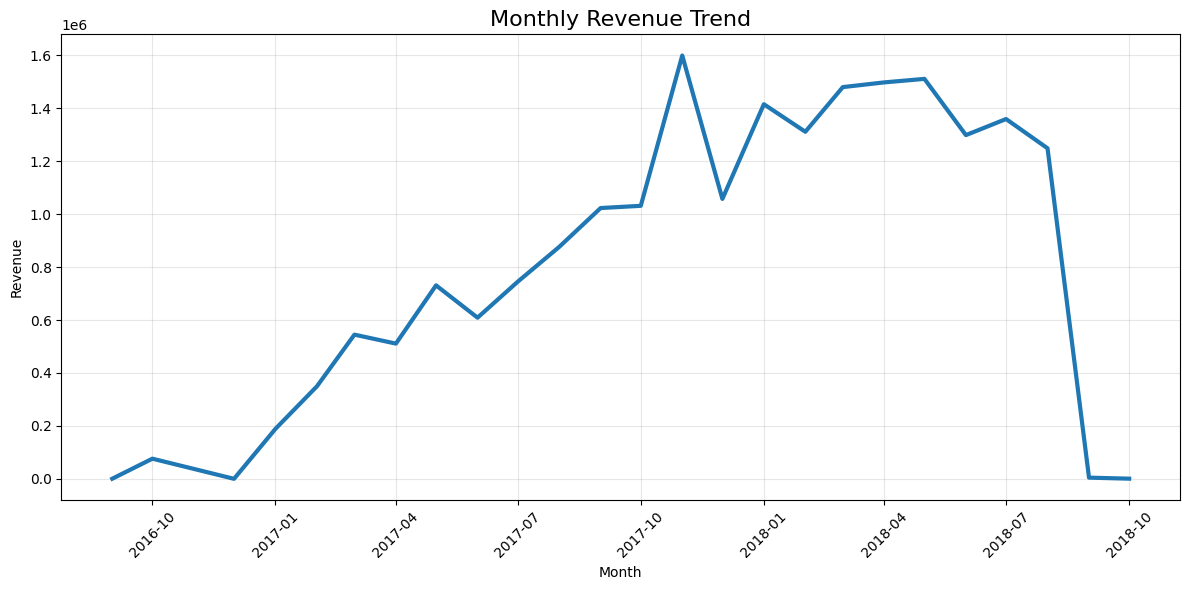

In [228]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["total_payment"],
    linewidth=3
)

plt.title("Monthly Revenue Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [230]:
monthly_revenue.sort_values(
    "total_payment",
    ascending=False
).head(10)

,purchase_year,purchase_month,total_payment,month
13,2017,11,1599444.18,2017-11-01
19,2018,5,1511113.00,2018-05-01
18,2018,4,1497843.94,2018-04-01
17,2018,3,1480045.50,2018-03-01
15,2018,1,1415348.54,2018-01-01
21,2018,7,1359421.48,2018-07-01
16,2018,2,1311260.71,2018-02-01
20,2018,6,1298685.81,2018-06-01
22,2018,8,1248837.93,2018-08-01
14,2017,12,1057582.34,2017-12-01


Business Insights

Monthly revenue shows a strong upward trend from early 2017 through mid-2018, indicating sustained business growth.
November 2017 generated the highest monthly revenue (~1.6M), likely influenced by seasonal shopping events such as Black Friday.
Revenue remained consistently high throughout 2018, demonstrating improved customer acquisition and retention.
The sharp decline in September–October 2018 is due to incomplete data rather than a true decrease in sales and should be excluded from trend analysis.

In [234]:
category_revenue = (
    master_df
    .groupby("product_category_name_english", as_index=False)
    .agg(
        total_revenue=("total_payment", "sum"),
        total_orders=("order_id", "nunique")
    )
    .sort_values("total_revenue", ascending=False)
)

category_revenue.head(10)

,product_category_name_english,total_revenue,total_orders
7,bed_bath_table,1712553.67,9417
43,health_beauty,1657373.12,8836
15,computers_accessories,1585330.45,6689
39,furniture_decor,1430176.39,6449
70,watches_gifts,1429216.68,5624
65,sports_leisure,1392127.56,7720
49,housewares,1094758.13,5884
5,auto,852294.33,3897
42,garden_tools,838280.75,3518
20,cool_stuff,779698.00,3632


**Business Insights**
- Bed Bath & Table is the highest revenue-generating category with ~1.71 million in revenue from 9,417 orders.
Health & Beauty and Computers & Accessories are also major revenue drivers, indicating strong customer demand for personal care and technology products.
- Categories such as Sports & Leisure generate many orders but comparatively lower revenue, suggesting lower average order values.
Revenue is concentrated within a small group of product categories, making them strategic areas for inventory planning, marketing campaigns, and promotional investments.

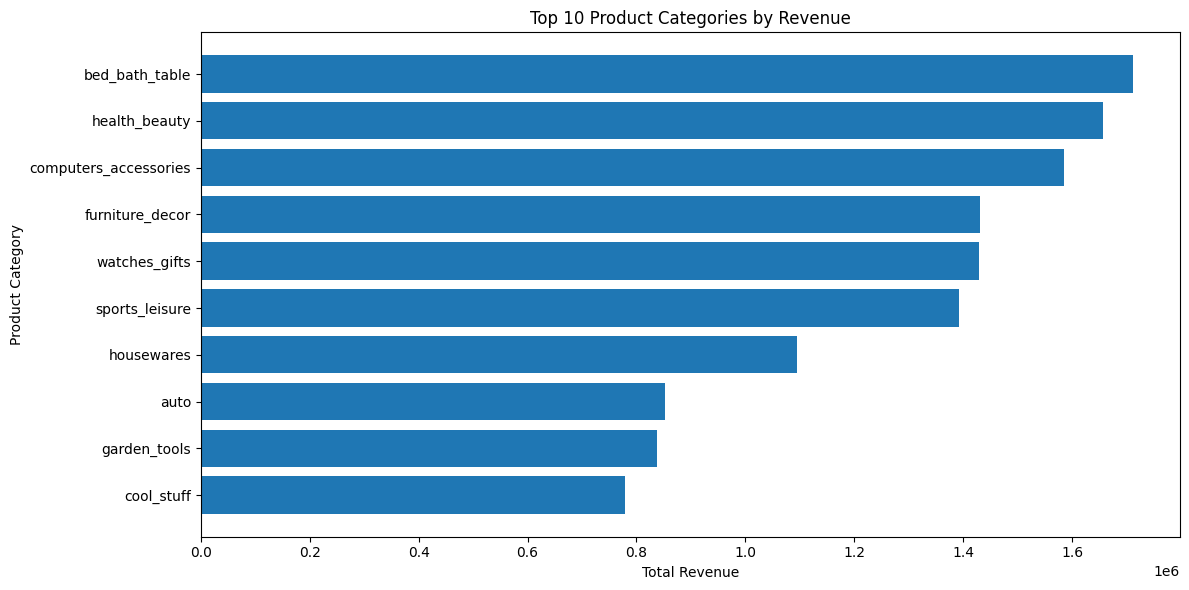

In [238]:
top10_categories = category_revenue.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10_categories["product_category_name_english"],
    top10_categories["total_revenue"]
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [240]:
# Revenue by Customer State

state_revenue = (
    master_df
    .groupby("customer_state", as_index=False)
    .agg(
        total_revenue=("total_payment", "sum"),
        total_orders=("order_id", "nunique"),
        unique_customers=("customer_unique_id", "nunique")
    )
)

state_revenue["avg_revenue_per_order"] = (
    state_revenue["total_revenue"] /
    state_revenue["total_orders"]
)

state_revenue = state_revenue.sort_values(
    "total_revenue",
    ascending=False
)

state_revenue.head(10)

,customer_state,total_revenue,total_orders,unique_customers,avg_revenue_per_order
25,SP,7673188.55,41746,40302,183.806558
18,RJ,2783724.26,12852,12384,216.598526
10,MG,2341861.47,11635,11259,201.277307
22,RS,1152019.17,5466,5277,210.760917
17,PR,1074614.19,5045,4882,213.005786
4,BA,802416.72,3380,3277,237.401396
23,SC,799135.92,3637,3534,219.723926
8,GO,516182.51,2020,1952,255.535896
6,DF,434512.55,2140,2075,203.043248
7,ES,406946.26,2033,1964,200.170320


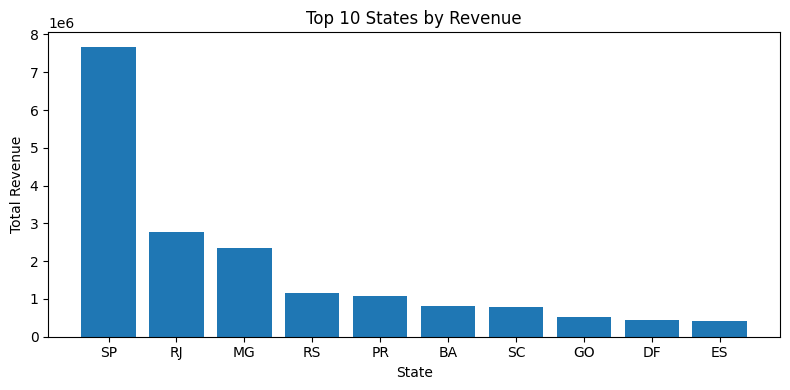

In [244]:
# Visualize Revenue by State

top10_states = state_revenue.head(10)

plt.figure(figsize=(8,4))

plt.bar(
    top10_states["customer_state"],
    top10_states["total_revenue"]
)

plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

**📒 Notebook Insights**

- São Paulo (SP) is the highest revenue-generating state, contributing over 7.6 million in revenue from more than 41,000 orders.
- Rio de Janeiro (RJ) and Minas Gerais (MG) are the next largest markets but generate significantly lower revenue than SP
- Revenue is highly concentrated in Brazil's southeastern states, indicating that these regions are the company's primary customer markets.
- States such as GO and BA have fewer customers but relatively higher average revenue per order, suggesting stronger purchasing power or higher-value purchases.

In [250]:
# Average Order Value by State

avg_order_state = (
    master_df
    .groupby("customer_state", as_index=False)
    .agg(
        avg_order_value=("total_payment", "mean"),
        total_orders=("order_id", "nunique")
    )
)

# Keep only states with at least 100 orders
avg_order_state = avg_order_state[
    avg_order_state["total_orders"] >= 100
]

avg_order_state = avg_order_state.sort_values(
    "avg_order_value",
    ascending=False
)

avg_order_state.head(10)

,customer_state,avg_order_value,total_orders
14,PB,299.580858,536
16,PI,251.981011,495
1,AL,251.107130,413
20,RO,243.607324,253
12,MT,243.104485,907
13,PA,241.873834,975
9,MA,240.569868,747
5,CE,233.811944,1336
24,SE,232.439590,350
26,TO,229.152152,280


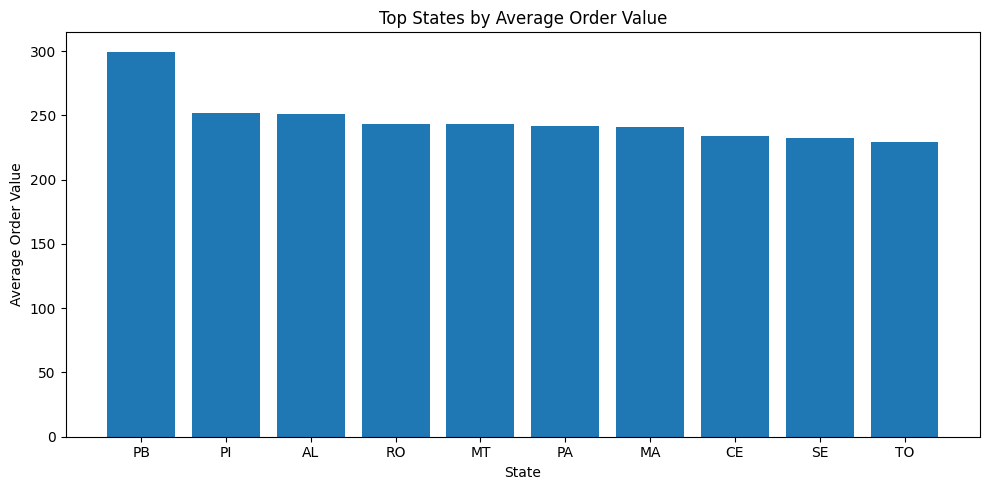

In [252]:
top_avg = avg_order_state.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_avg["customer_state"],
    top_avg["avg_order_value"]
)

plt.title("Top States by Average Order Value")
plt.xlabel("State")
plt.ylabel("Average Order Value")

plt.tight_layout()
plt.show()

## 📊 Business Insights

- **Paraíba (PB)** has the highest average order value (**~299.58**), indicating that customers in this state spend significantly more per purchase despite having a relatively low number of orders.
- States such as **Piauí (PI)**, **Alagoas (AL)**, and **Rondônia (RO)** also exhibit high average order values, suggesting strong purchasing behavior in these regions.
- High-revenue states are not always the states with the highest average order values. While **São Paulo (SP)** dominates total revenue due to its large customer base, several smaller states generate higher spending per order.
- These findings can help the business identify premium markets where targeted marketing campaigns, high-value product recommendations, and customer retention strategies may generate higher returns.

### 📌 Business Recommendation

Focus premium product promotions and personalized marketing campaigns on states with higher average order values while continuing customer acquisition efforts in high-volume states such as São Paulo.

In [255]:
# Average Rating by Product Category

category_rating = (
    master_df
    .groupby("product_category_name_english", as_index=False)
    .agg(
        avg_rating=("review_score", "mean"),
        total_reviews=("review_id", "count"),
        total_orders=("order_id", "nunique")
    )
)

# Keep only categories with at least 100 reviews
category_rating = category_rating[
    category_rating["total_reviews"] >= 100
]

category_rating = category_rating.sort_values(
    "avg_rating",
    ascending=False
)

category_rating.head(10)

,product_category_name_english,avg_rating,total_reviews,total_orders
8,books_general_interest,4.446266,549,512
10,books_technical,4.363636,264,260
53,luggage_accessories,4.315257,1088,1034
37,food_drink,4.310469,277,227
31,fashion_shoes,4.228682,258,240
36,food,4.218182,495,450
66,stationery,4.196078,2499,2311
60,pet_shop,4.184306,1937,1710
14,computers,4.175000,200,181
59,perfumery,4.165932,3405,3162


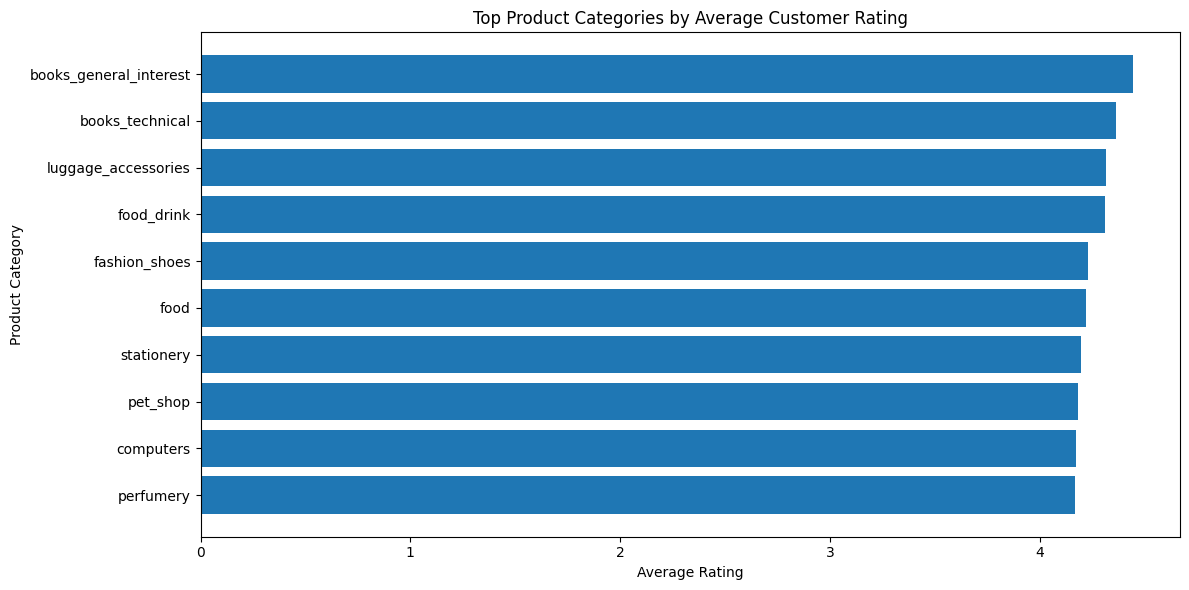

In [257]:
top_rating = category_rating.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_rating["product_category_name_english"],
    top_rating["avg_rating"]
)

plt.gca().invert_yaxis()

plt.title("Top Product Categories by Average Customer Rating")
plt.xlabel("Average Rating")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

In [259]:
category_rating.sort_values(
    "avg_rating"
).head(10)

,product_category_name_english,avg_rating,total_reviews,total_orders
57,office_furniture,3.491950,1677,1273
30,fashion_male_clothing,3.641221,131,112
34,fixed_telephony,3.681992,261,217
47,home_confort,3.831019,432,397
4,audio,3.833333,360,350
19,construction_tools_safety,3.844560,193,167
7,bed_bath_table,3.898470,10982,9417
40,furniture_living_room,3.901606,498,422
39,furniture_decor,3.906788,8250,6449
15,computers_accessories,3.932537,7782,6689


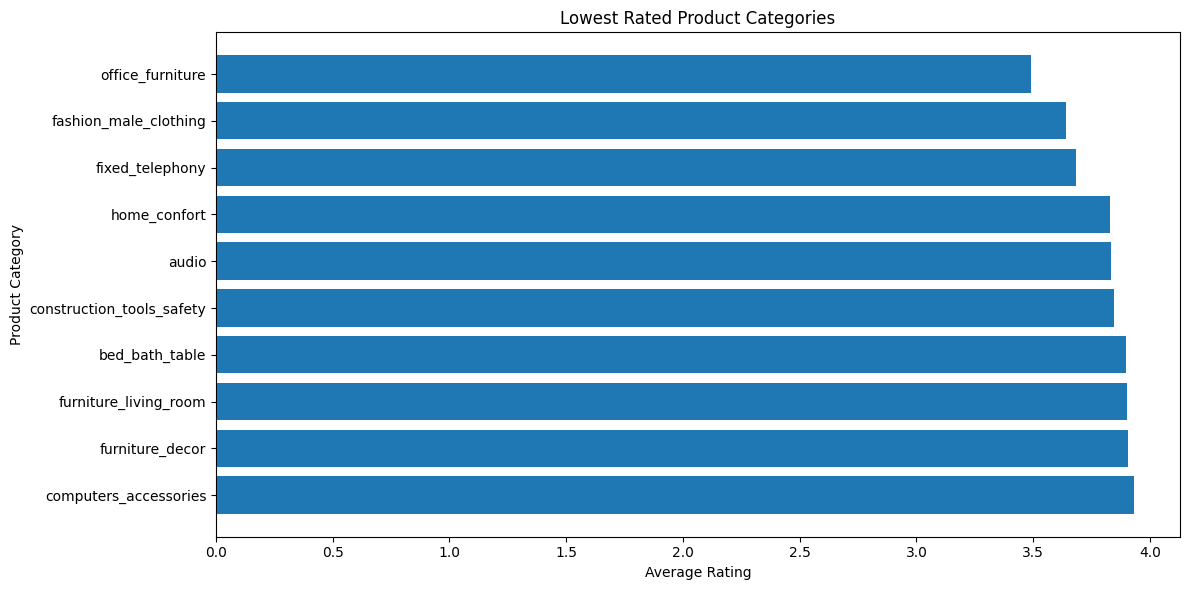

In [261]:
bottom_rating = category_rating.sort_values(
    "avg_rating"
).head(10)

plt.figure(figsize=(12,6))

plt.barh(
    bottom_rating["product_category_name_english"],
    bottom_rating["avg_rating"]
)

plt.gca().invert_yaxis()

plt.title("Lowest Rated Product Categories")
plt.xlabel("Average Rating")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

## 📊 Business Insights

- **Books (General Interest)** received the highest average customer rating (**4.45/5**), followed by **Books (Technical)** and **Luggage & Accessories**, indicating consistently high customer satisfaction in these categories.
- Categories such as **Office Furniture**, **Fashion Male Clothing**, and **Fixed Telephony** received the lowest average ratings, suggesting potential issues related to product quality, delivery experience, or customer expectations.
- The highest revenue-generating category (**Bed Bath & Table**) appears among the lower-rated categories, showing that strong sales do not necessarily translate into high customer satisfaction.
- Product categories with consistently high ratings present opportunities for customer retention, while lower-rated categories should be prioritized for quality improvement and service optimization.

### 📌 Business Recommendation

Investigate the root causes of low customer ratings in categories such as **Office Furniture** and **Bed Bath & Table** by analyzing delivery delays, product returns, and customer feedback. Improving customer experience in these high-impact categories can increase repeat purchases and strengthen long-term customer loyalty.

In [264]:
# Delivery Performance Analysis

delivery_rating = (
    master_df
    .groupby("delivery_status", as_index=False)
    .agg(
        avg_rating=("review_score", "mean"),
        total_orders=("order_id", "nunique"),
        avg_delivery_days=("delivery_days", "mean")
    )
)

delivery_rating

,delivery_status,avg_rating,total_orders,avg_delivery_days
0,Late,2.099224,9500,33.329525
1,On Time,4.208183,89941,10.502803


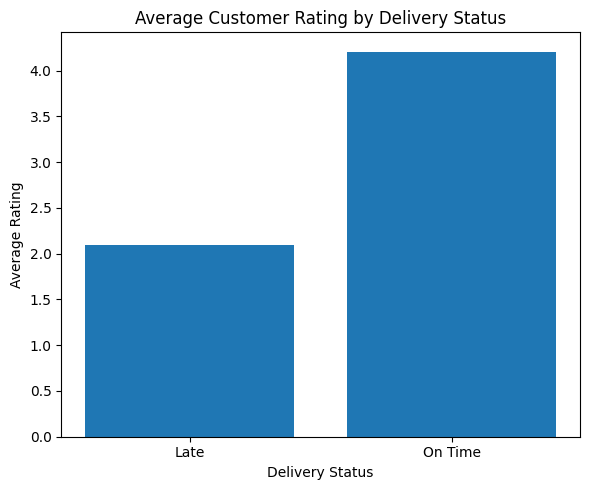

In [266]:
plt.figure(figsize=(6,5))

plt.bar(
    delivery_rating["delivery_status"],
    delivery_rating["avg_rating"]
)

plt.title("Average Customer Rating by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Rating")

plt.tight_layout()
plt.show()

## 📊 Business Insights

- Customers whose orders were **delivered on time** gave an average rating of **4.21/5**, while customers experiencing **late deliveries** gave an average rating of only **2.10/5**.
- Late deliveries account for **9,500** orders with an average delivery time of **33.33 days**, whereas on-time deliveries average only **10.50 days**.
- Customer satisfaction decreases significantly when deliveries are delayed, highlighting delivery performance as one of the most influential factors affecting customer experience.
- Maintaining on-time delivery performance is essential for achieving higher customer ratings, improving customer loyalty, and encouraging repeat purchases.

### 📌 Business Recommendation

Prioritize logistics optimization to minimize delivery delays by improving warehouse operations, courier performance, and inventory planning. Even a small reduction in late deliveries can lead to a significant improvement in customer satisfaction and long-term customer retention.

In [269]:
# Correlation Analysis

correlation_df = master_df[
    [
        "review_score",
        "delivery_delay_days",
        "delivery_days",
        "estimated_delivery_days",
        "approval_time_hours",
        "total_payment",
        "freight_percentage"
    ]
]

correlation_df.corr(numeric_only=True)

,review_score,delivery_delay_days,delivery_days,estimated_delivery_days,approval_time_hours,total_payment,freight_percentage
review_score,1.000000,-0.229381,-0.304687,-0.061152,-0.027264,-0.084330,-0.033584
delivery_delay_days,-0.229381,1.000000,0.597315,-0.511399,0.042351,-0.020800,-0.035263
delivery_days,-0.304687,0.597315,1.000000,0.382290,0.084426,0.063018,0.082099
estimated_delivery_days,-0.061152,-0.511399,0.382290,1.000000,0.041084,0.089315,0.127348
approval_time_hours,-0.027264,0.042351,0.084426,0.041084,1.000000,0.043671,0.032693
total_payment,-0.084330,-0.020800,0.063018,0.089315,0.043671,1.000000,-0.313035
freight_percentage,-0.033584,-0.035263,0.082099,0.127348,0.032693,-0.313035,1.000000


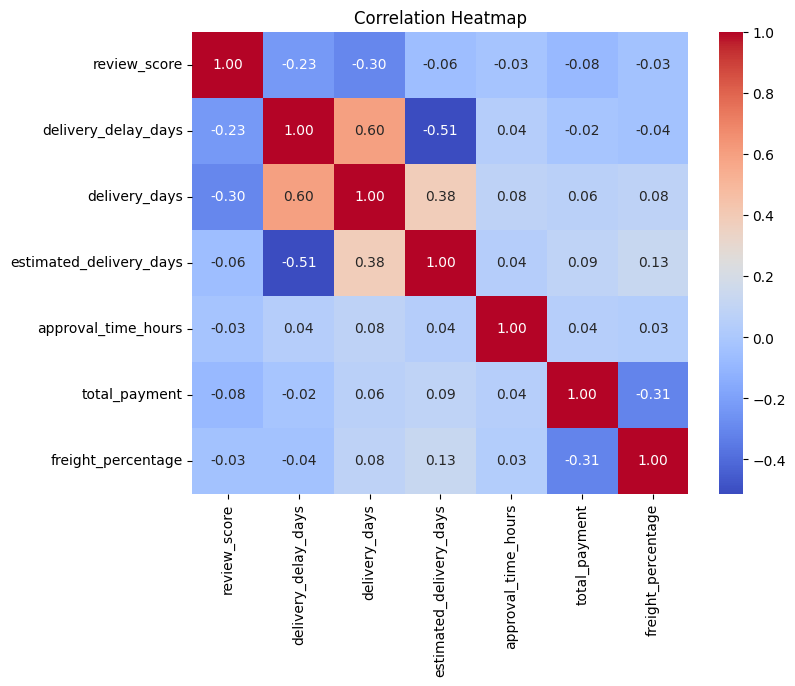

In [271]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## 📊 Business Insights

- **Customer ratings show a moderate negative correlation (-0.30) with delivery days**, indicating that customers tend to give lower ratings as delivery time increases.
- **Delivery delay days also have a negative correlation (-0.23) with review scores**, confirming that delayed deliveries reduce customer satisfaction.
- **Delivery days and delivery delay days are positively correlated (0.60)**, showing that longer delivery times increase the likelihood of delivery delays.
- **Estimated delivery days have a moderate negative correlation (-0.51) with delivery delay days**, suggesting that orders with longer estimated delivery windows are less likely to be classified as delayed.
- Variables such as **approval time, total payment, and freight percentage** show very weak correlations with customer ratings, indicating that delivery performance has a much stronger impact on customer satisfaction than pricing or payment-related factors.

### 📌 Business Recommendation

Improving delivery speed and reducing delivery delays should be a key business priority, as logistics performance has a measurable impact on customer satisfaction. Investing in faster fulfillment and more reliable shipping partners can help increase customer ratings and improve customer retention.

In [274]:
# Seller Performance Analysis
# Which sellers contribute the most revenue while maintaining high customer satisfaction?

seller_performance = (
    master_df
    .groupby("seller_id", as_index=False)
    .agg(
        total_revenue=("total_payment", "sum"),
        total_orders=("order_id", "nunique"),
        avg_rating=("review_score", "mean")
    )
)

seller_performance = seller_performance.sort_values(
    "total_revenue",
    ascending=False
)

seller_performance.head(10)

,seller_id,total_revenue,total_orders,avg_rating
1535,7c67e1448b00f6e969d365cea6b010ab,507166.91,982,3.345133
192,1025f0e2d44d7041d6cf58b6550e0bfa,308222.04,915,3.846045
881,4a3ca9315b744ce9f8e9374361493884,301245.27,1806,3.803772
368,1f50f920176fa81dab994f9023523100,290253.42,1404,3.988040
1013,53243585a1d6dc2643021fd1853d8905,284903.08,358,4.075980
2643,da8622b14eb17ae2831f4ac5b9dab84a,272219.32,1314,4.067314
857,4869f7a5dfa277a7dca6462dcf3b52b2,264166.12,1132,4.122822
1824,955fee9216a65b617aa5c0531780ce60,236322.30,1287,4.050437
3024,fa1c13f2614d7b5c4749cbc52fecda94,206513.23,585,4.340206
1560,7e93a43ef30c4f03f38b393420bc753a,185134.21,336,4.206490


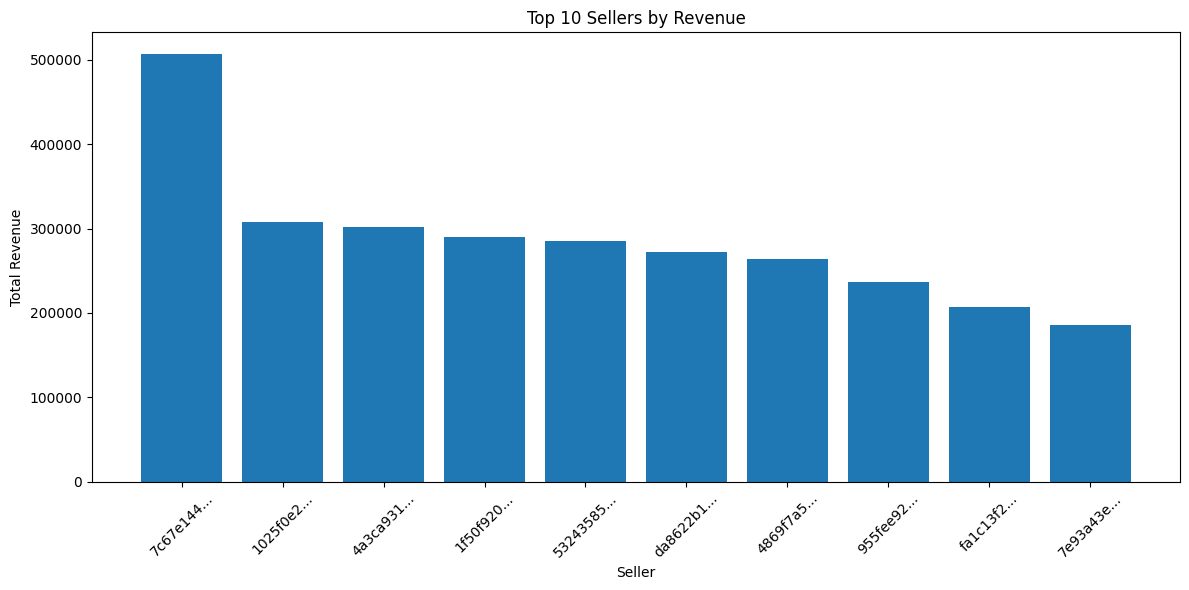

In [276]:
top_sellers = seller_performance.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    range(len(top_sellers)),
    top_sellers["total_revenue"]
)

plt.xticks(
    range(len(top_sellers)),
    [sid[:8] + "..." for sid in top_sellers["seller_id"]],
    rotation=45
)

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Seller")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

In [278]:
# save the engineered dataset

master_df.to_csv(
    "olist_master_dataset.csv",
    index=False
)

print("Dataset exported successfully!")
print(master_df.shape)

Dataset exported successfully!
(113425, 63)
